In [1]:
from background_db import *
import matplotlib.pyplot as plt

# Make background DB

## test for 1 energy range

/Users/tbastro/SPI_analysis/BACKGROUND/BG_SAV/PSD/com_spec_params_e490_530_revidx_0043-2887.sav


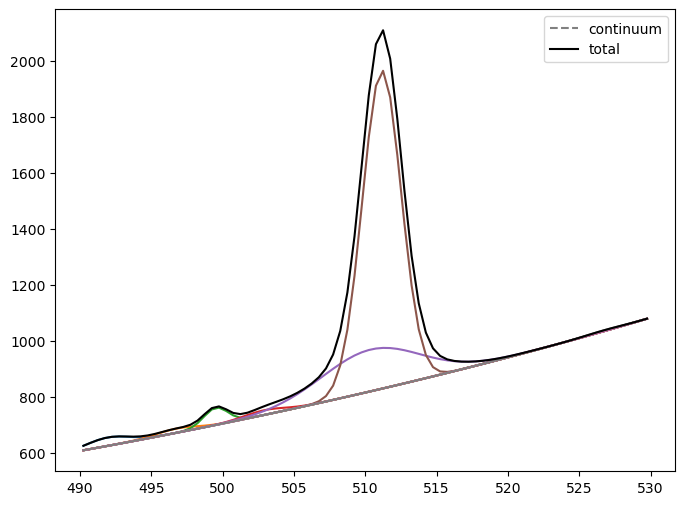

array([ 944,  945,  946,  947,  948,  949,  950,  951,  952,  953,  954,
        955,  956,  957,  958,  959,  960,  961,  962,  963,  964,  965,
        966,  967,  968,  969,  970,  971,  972,  973,  974,  975,  976,
        977,  978,  979,  980,  981,  982,  983,  984,  985,  986,  987,
        988,  989,  990,  991,  992,  993,  994,  995,  996,  997,  998,
        999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009,
       1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020,
       1021, 1022, 1023], dtype='>i4')

In [2]:
# spec_param_dir = '/data1/ipp_afs_mirror/integral/data/databases/spi_line_db/data/save/0043-2877'
evt_type='PSD'
rev_start, rev_stop = '0043', '2887' # 356_408
spec_param_dir= '/Users/tbastro/SPI_analysis/BACKGROUND/BG_SAV'
spec_params_path_list = glob(f'{spec_param_dir}/{evt_type}/com_spec_params_e*_revidx_{rev_start}-{rev_stop}.sav')
spec_params_path_list = order_path_list(spec_params_path_list)

spec_param_file=spec_params_path_list[0]
print(spec_param_file)
bkg = BkgEband(evt_type, '', spec_param_file)
for ndet in range(1):
    bkg.calc_spec_rev_det_eband(nrev=100, ndet=ndet, E=None, plot=True)
    plt.show()
bkg.idx_range

## all energy range

<Axes: title={'center': 'rev 45 det 0'}, xlabel='E (keV)', ylabel='rate (ct/kev)'>

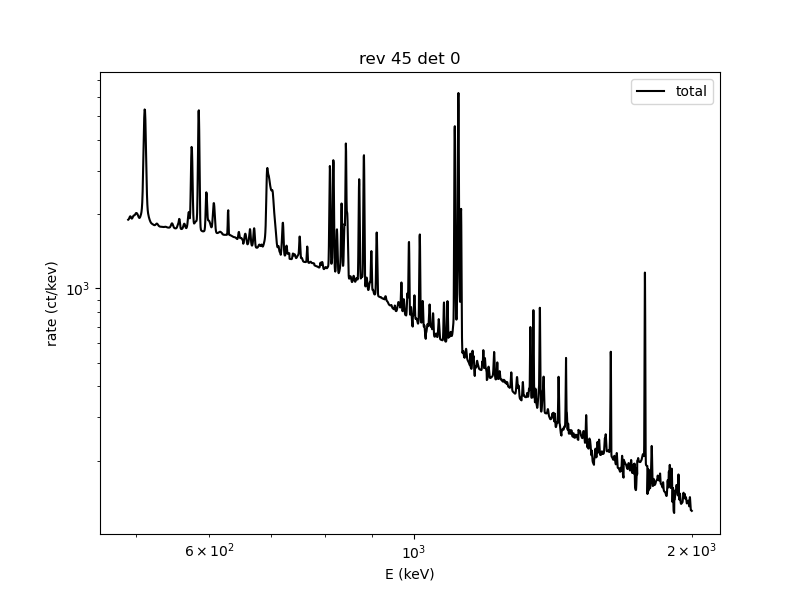

In [3]:
bkg_full = BkgList(spec_params_path_list, evt_type=evt_type)
bkg_full.calc_spec_rev_det(nrev=45, ndet=0)
%matplotlib widget
bkg_full.plot()

In [4]:
revolutions=np.arange(40, 45, dtype='int64')
# revolutions=np.arange(40, 45, dtype='int64')
bkg_full.write_fits_files(output_dir=f'/Users/tbastro/SPI_analysis/BACKGROUND/BKG_DB/{evt_type}', revolutions=revolutions, compress=True)

 40%|████      | 2/5 [00:00<00:00, 18.91it/s]

No background for rev 40.
No background for rev 41.
No background for rev 42.


100%|██████████| 5/5 [00:00<00:00, 12.29it/s]


# Create scw background

In [1]:
from obs_background import *

## test 1 obs

loading scw info
load energy bounds
loading observation live times
Initialize data base meta
Initialize revolution backgrounds from data base
Available background types: ['CONTINUUM', 'LINES']
Shape of first background type: (1216, 41, 2)


<Axes: title={'center': 'Background (scw 0, det 0)'}, xlabel='Energy (keV)', ylabel='Counts'>

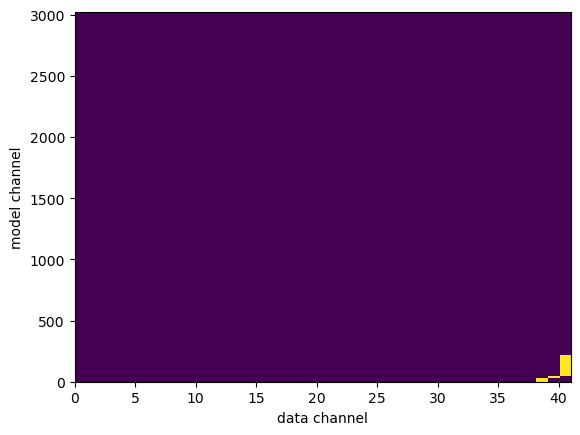

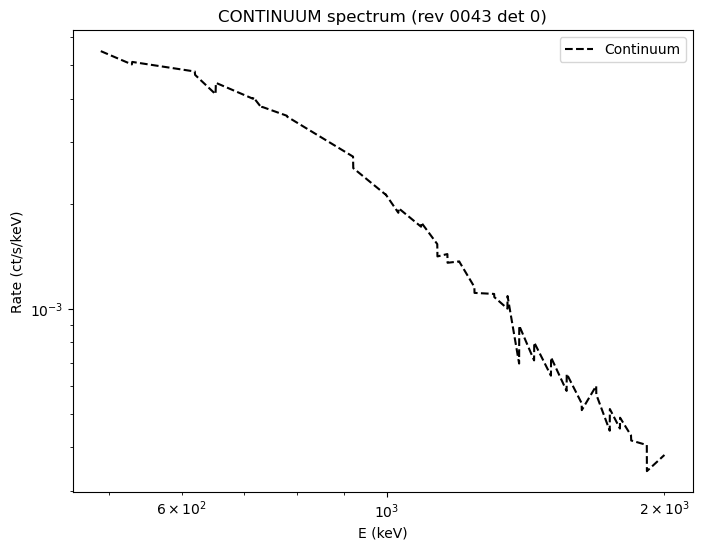

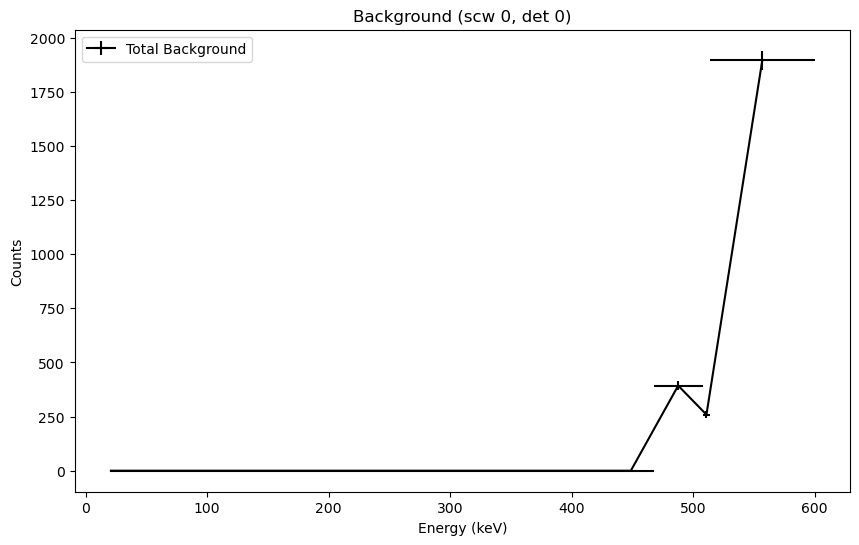

In [7]:
# %matplotlib widget
evt_type='PSD'
main_dir = '/Users/tbastro/SPI_analysis/BACKGROUND/crab_dir_test'
bkg_db_dir = '/Users/tbastro/SPI_analysis/BACKGROUND/BKG_DB'
obs_bkg = ObsBkg(main_dir, evt_type)
livetime_se = LiveTimeRev(bkg_db_dir+'/det_livetime_rev.fits',evt_type)
obs_bkg.normalize_tracer(livetime_se)
obs_bkg.init_rev_bkg_list(livetime_rev=livetime_se, bkg_db_dir=bkg_db_dir)
obs_bkg.bkg_rev_list[0].plot_rbn_mat()
obs_bkg.bkg_rev_list[0].plot(det=0)

bkg_dict = obs_bkg.calc_bkg()
print("Available background types:", list(bkg_dict.keys()))
print("Shape of first background type:", bkg_dict[list(bkg_dict.keys())[0]].shape)
obs_bkg.plot_bkg(scw_idx=0, det=0, bkg_types=None, type_spec='counts')

In [3]:
obs_bkg.write_output_bkg('./output_test')

Written ./output_test/output_bgmodel-conti.fits.gz
Written ./output_test/output_bgmodel-lines.fits.gz
Written ./output_test/output_bgmodel_conti_sep_idx.fits.gz


## per detector

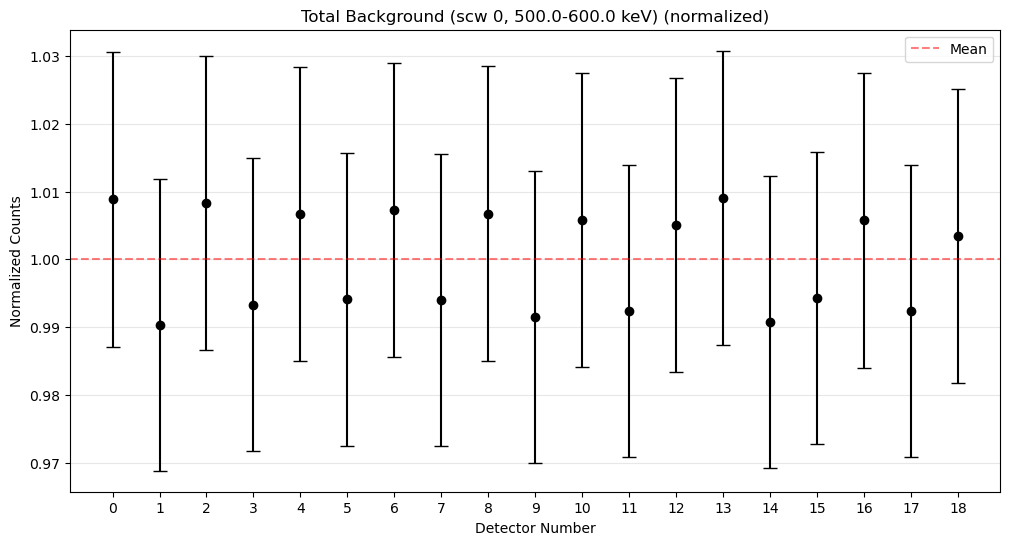

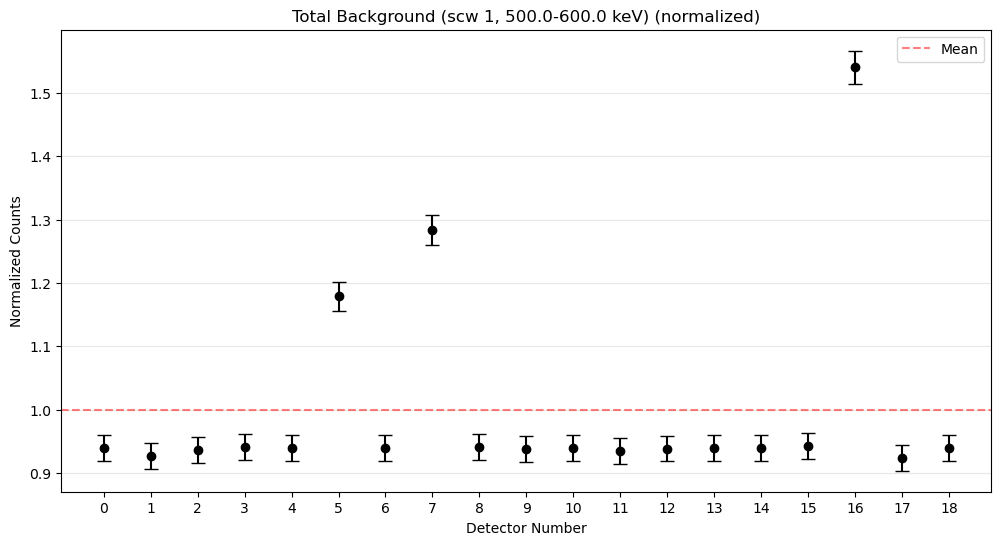

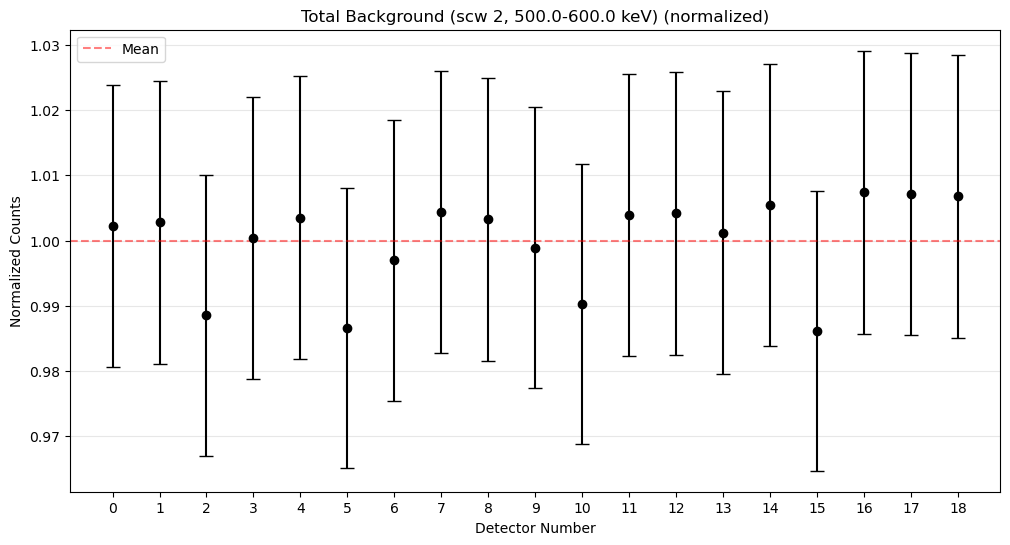

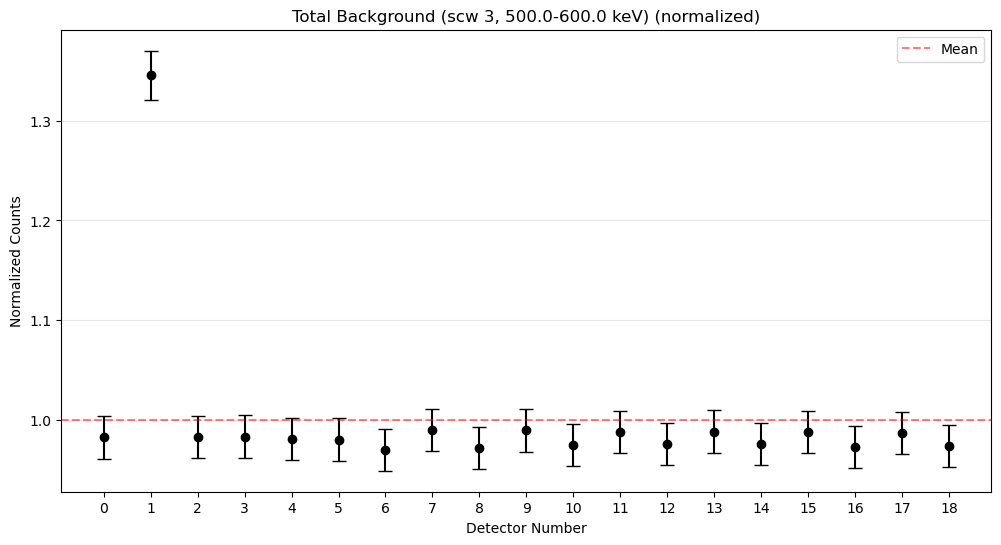

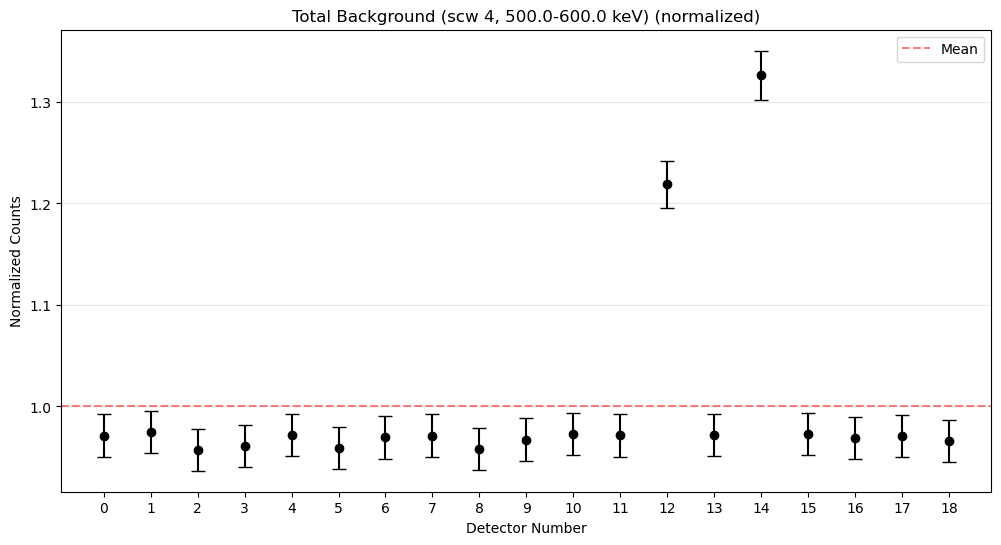

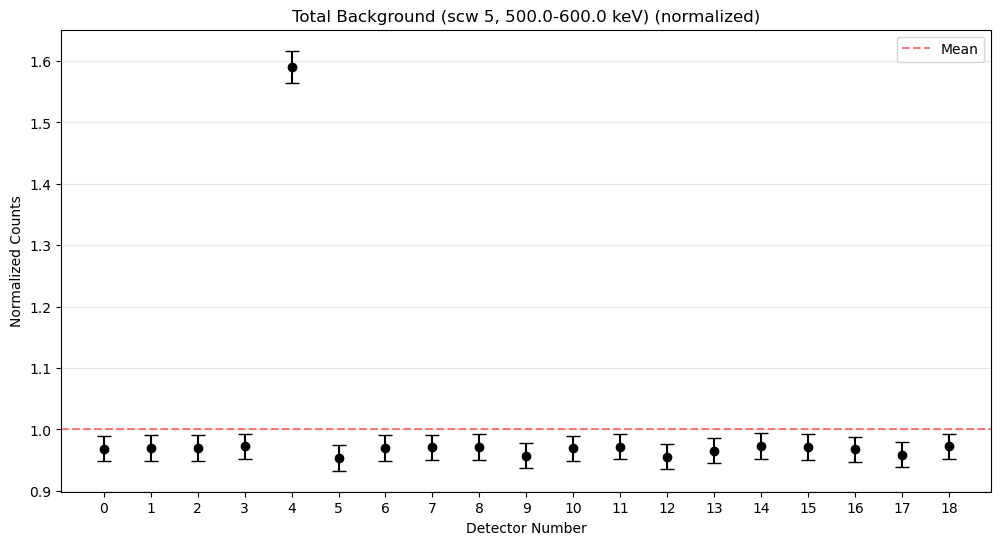

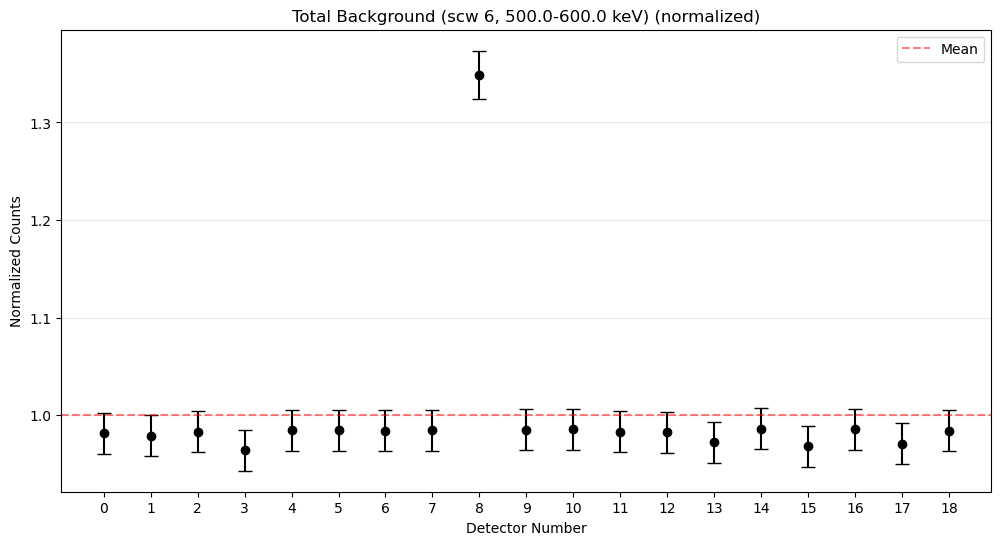

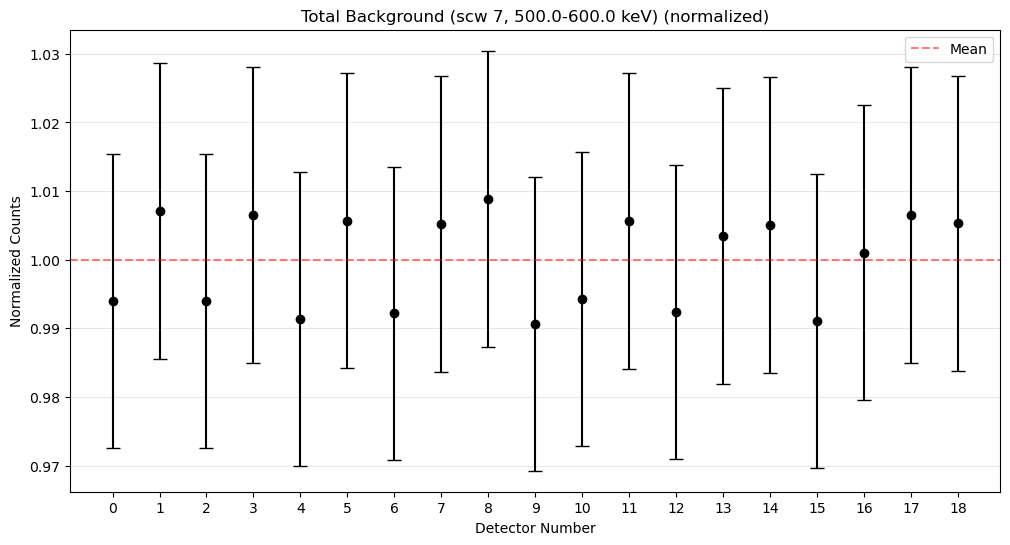

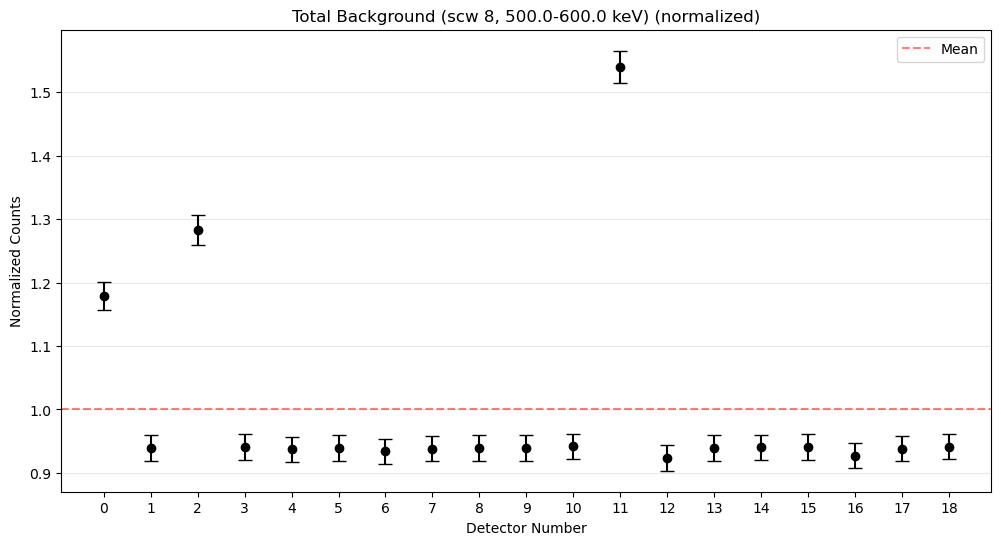

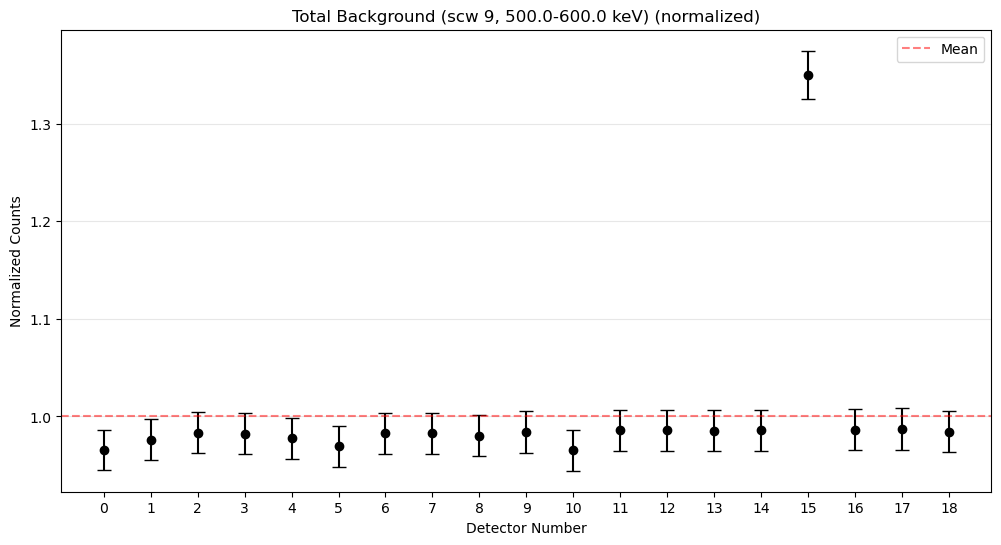

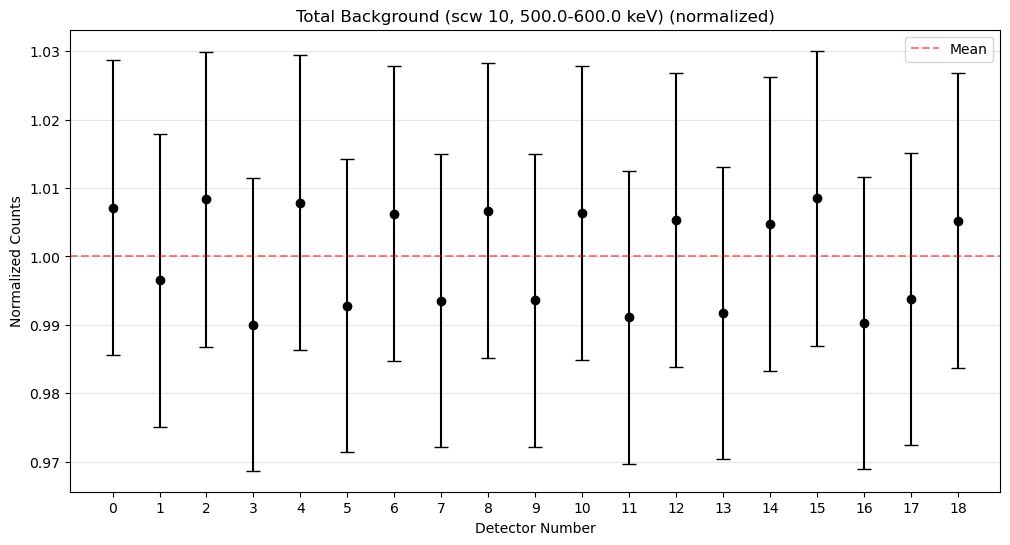

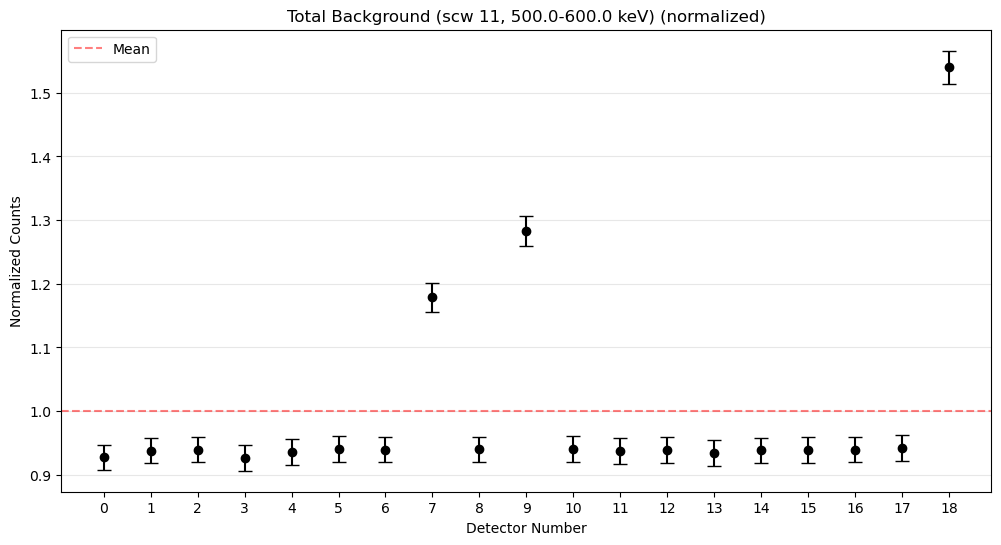

In [4]:
for scw_idx in range(12):
    ax=obs_bkg.plot_bkg_by_detector(scw_idx, 500, 600, None, normalize=True)
    # ax=obs_bkg.plot_bkg_by_detector(scw_idx, 30, 40, 'LINES', normalize=True)
    plt.show()

## comparison

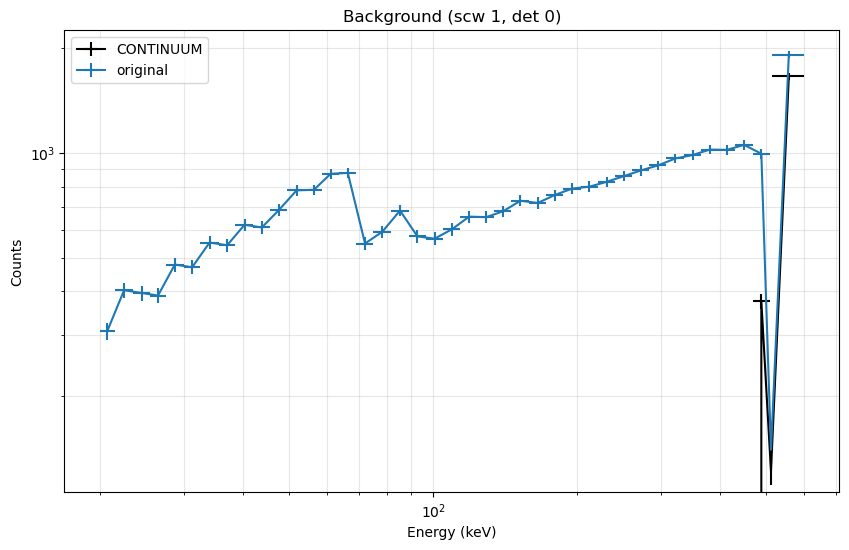

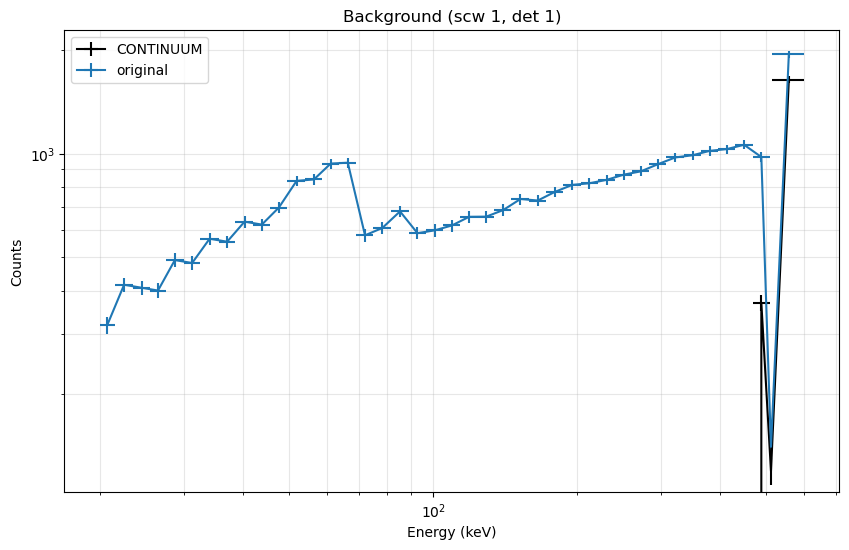

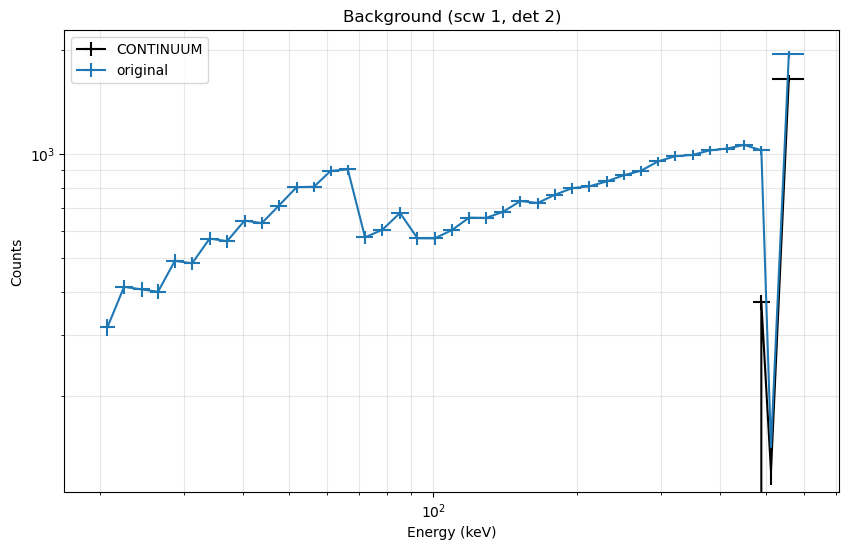

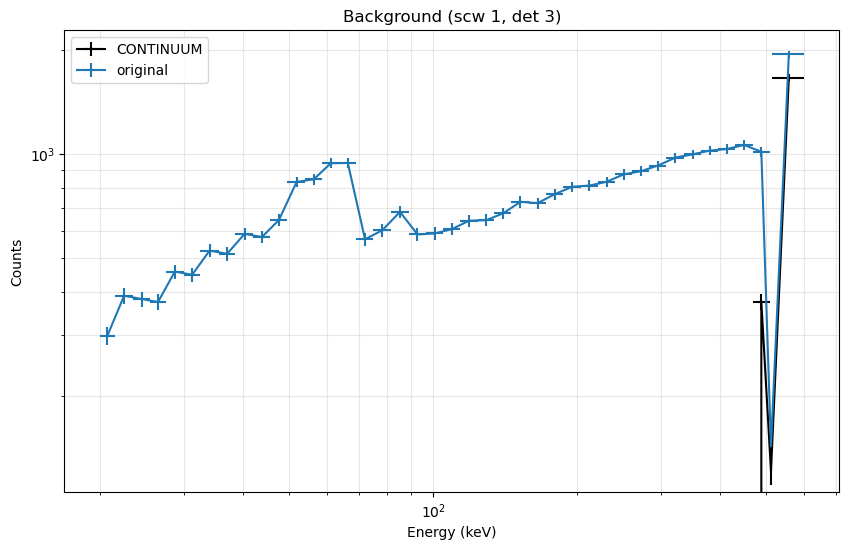

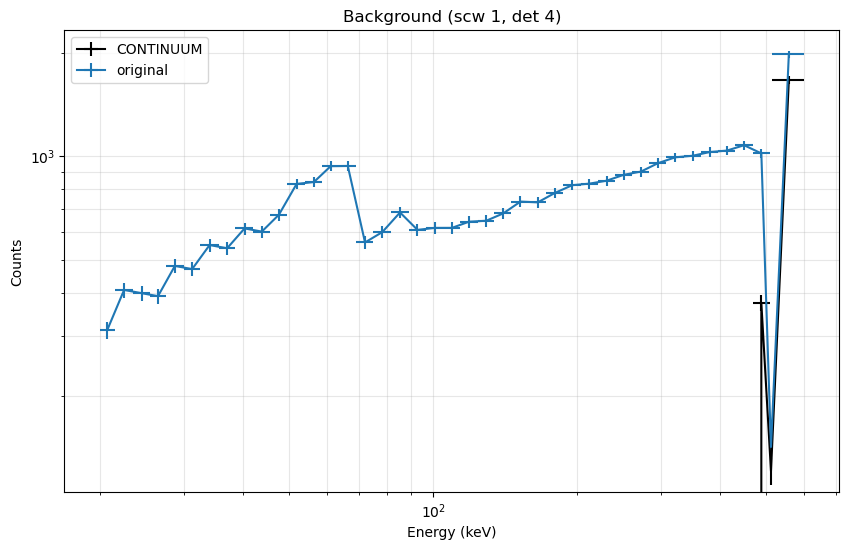

In [5]:
# %matplotlib widget
def check_output(dir='background_output/', file='output_bgmodel-conti.fits'):
    hdul=fits.open(dir+file)
    data=hdul[1].data
    return data

# out_dir='cookbook_dataset_02_0020-0600keV_SE/spi/bg-e0020-0600/' # old cookbook directory from 2013 
out_dir=f'/Users/tbastro/SPI_analysis/BACKGROUND/cookbook_dataset_02_0020-0600keV_SE_new/spi/bg-e0020-0600/' # fresh analysis from 2024
data_conti=check_output(dir=out_dir, file='output_bgmodel-conti.fits.gz')
data_sumlines=check_output(dir=out_dir, file='output_bgmodel-lines.fits.gz')
scw_idx = 1
bkg_type='CONTINUUM'
for det in range(5):
    ax = obs_bkg.plot_bkg(scw_idx=scw_idx, det=det, bkg_types=[bkg_type], type_spec='counts')
    if bkg_type=='LINES':
        ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y= data_sumlines[scw_idx*19+det][0], yerr=data_sumlines[scw_idx*19+det][1],label='original')
        ax.set_xscale('log')
    elif bkg_type=='CONTINUUM':
        ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y= data_conti[scw_idx*19+det][0], yerr=data_conti[scw_idx*19+det][1],label='original')
        ax.loglog()
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.show()

det 0 scw 6: ratio stderr 2.1e-02
det 1 scw 6: ratio stderr 7.8e-04 (<1e-3)
det 2 scw 6: ratio stderr 1.9e-02
det 3 scw 6: ratio stderr 3.2e-02
det 4 scw 6: ratio stderr 1.9e-02
det 5 scw 6: ratio stderr 1.6e-02
det 6 scw 6: ratio stderr 1.3e-02
det 7 scw 6: ratio stderr 3.1e-02
det 8 scw 6: ratio stderr 3.1e-02
det 9 scw 6: ratio stderr 2.8e-02
det 10 scw 6: ratio stderr 4.2e-02
det 11 scw 6: ratio stderr 3.0e-02
det 12 scw 6: ratio stderr 3.9e-02
det 13 scw 6: ratio stderr 7.0e-02
det 14 scw 6: ratio stderr 4.2e-02
det 15 scw 6: ratio stderr 4.3e-02
det 16 scw 6: ratio stderr 4.3e-02
det 17 scw 6: ratio stderr 5.9e-02
det 18 scw 6: ratio stderr 4.2e-02


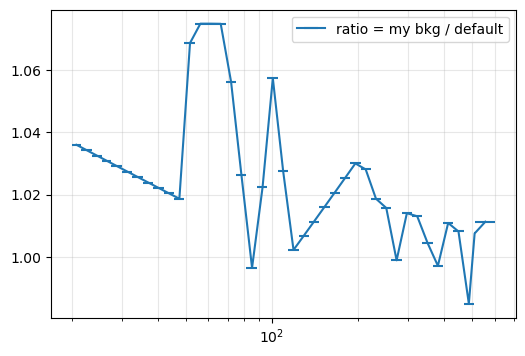

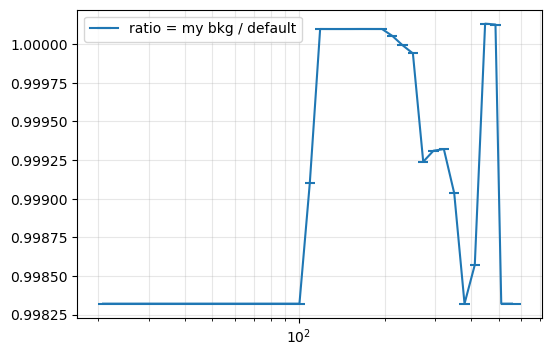

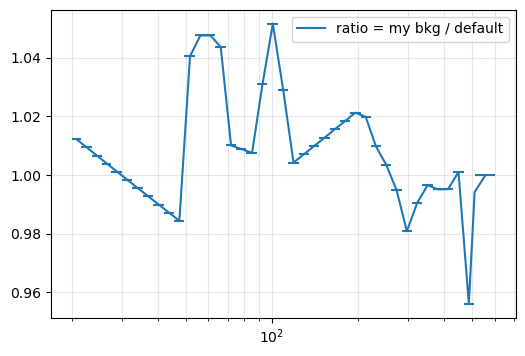

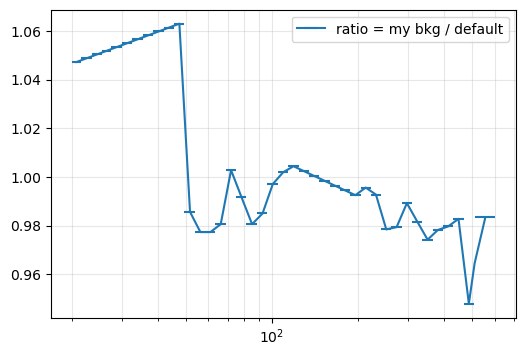

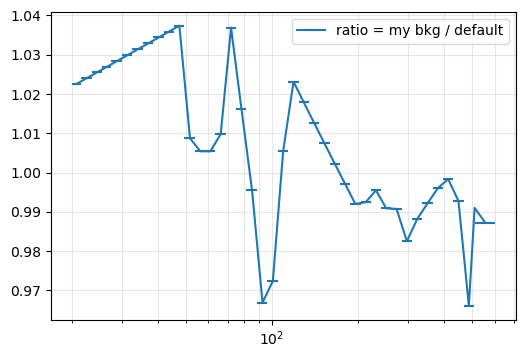

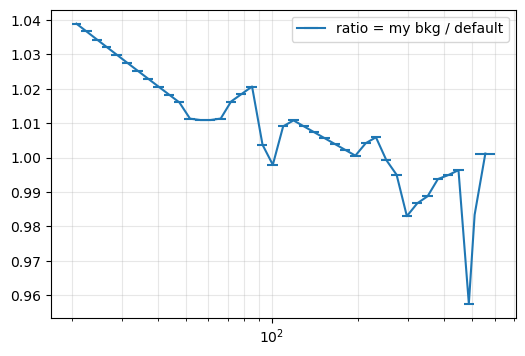

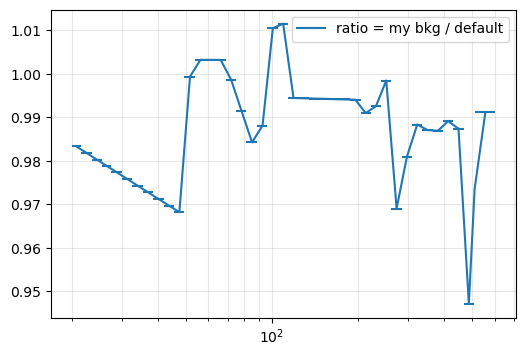

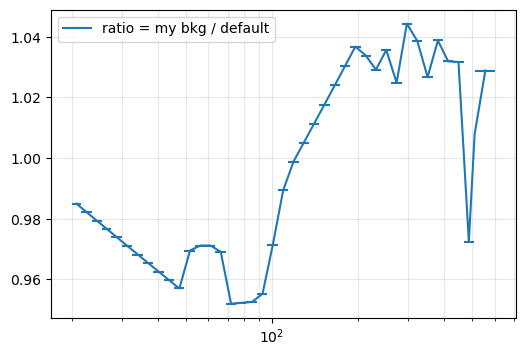

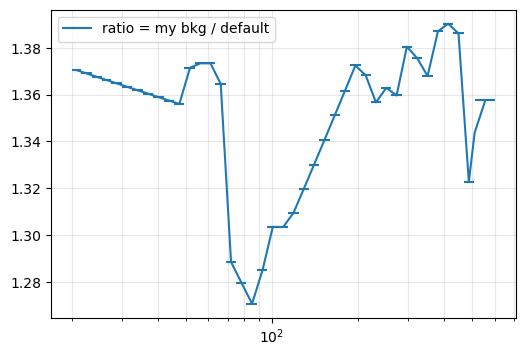

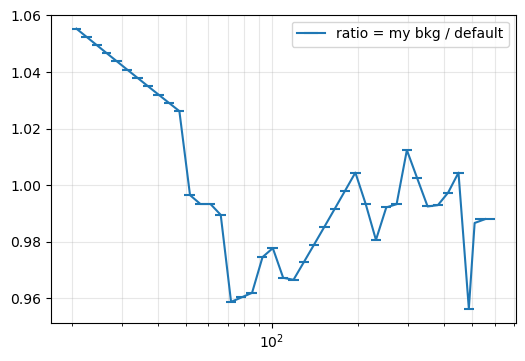

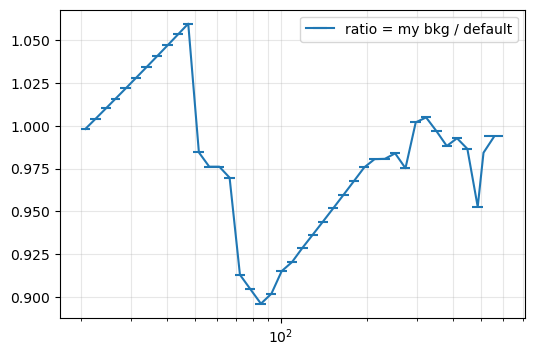

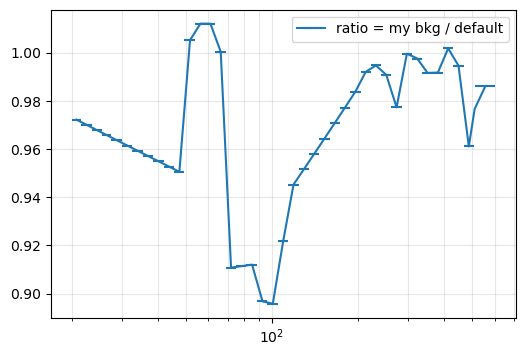

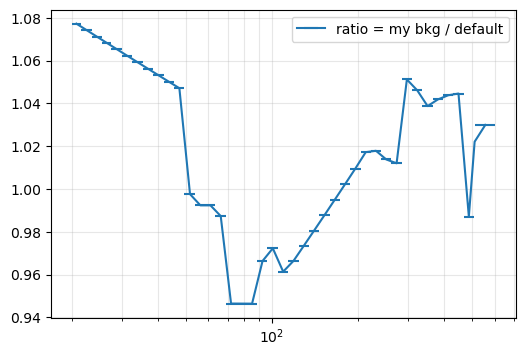

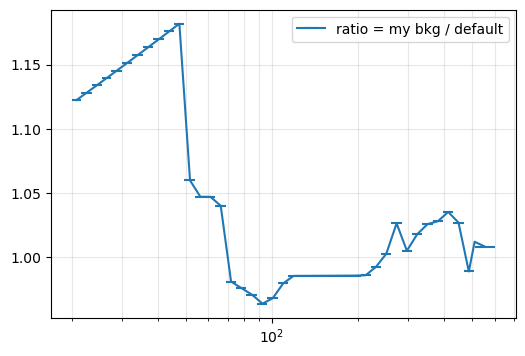

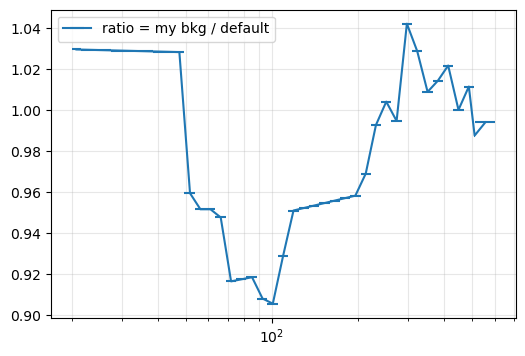

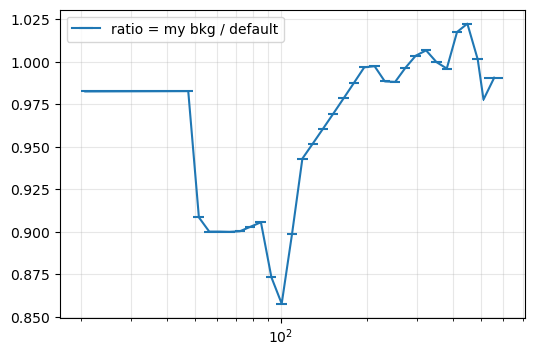

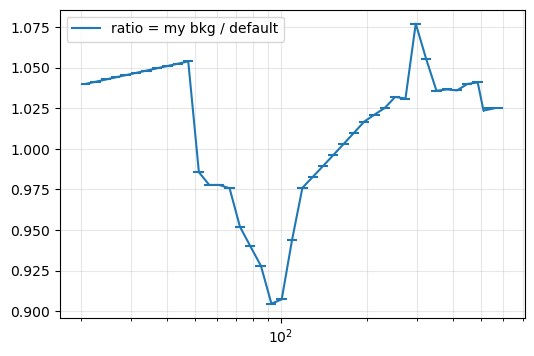

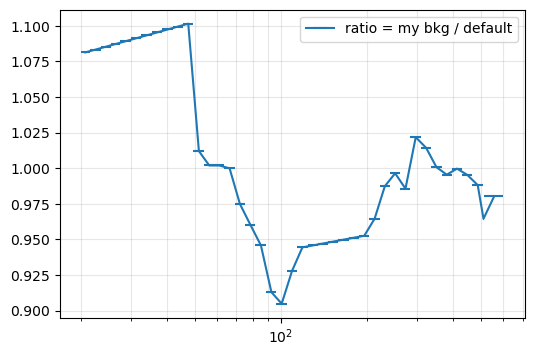

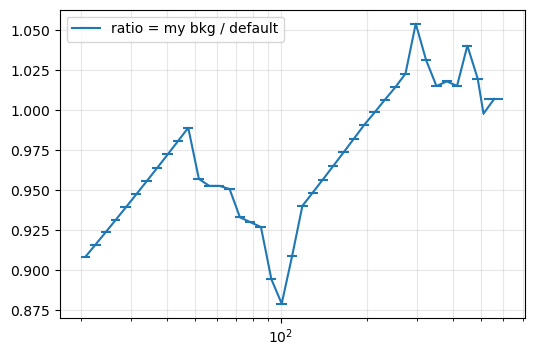

In [11]:
%matplotlib inline
scw_idx=6
for det in range(19):
    print(f'det {det} scw {scw_idx}: ', end='')
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ratio=obs_bkg.bkg_output_dico['CONTINUUM'][det + obs_bkg.det_num * scw_idx][:,0] / data_conti[scw_idx*19+det][0]
    # ratio=obs_bkg.bkg_output_dico['LINES'][det + obs_bkg.det_num * scw_idx] / data_sumlines[scw_idx*19+det][0]
    print(f'ratio stderr {ratio.std():.1e}'+int(ratio.std()<1e-3)*' (<1e-3)')
    ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y=ratio,label='ratio = my bkg / default')
    # ratio=obs_bkg.bkg_output_dico['CONTINUUM'][det + obs_bkg.det_num * scw_idx] / data[scw_idx*19+det][0]
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    # plt.show()

## raw spectrum

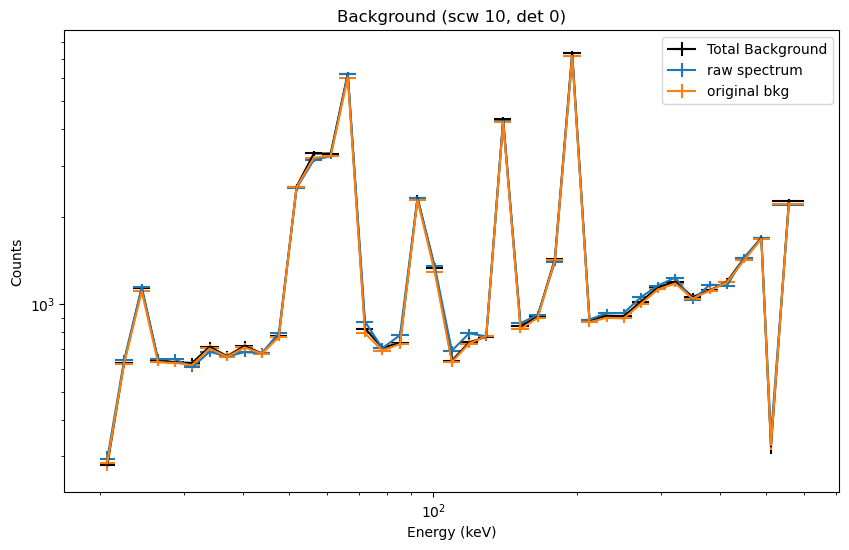

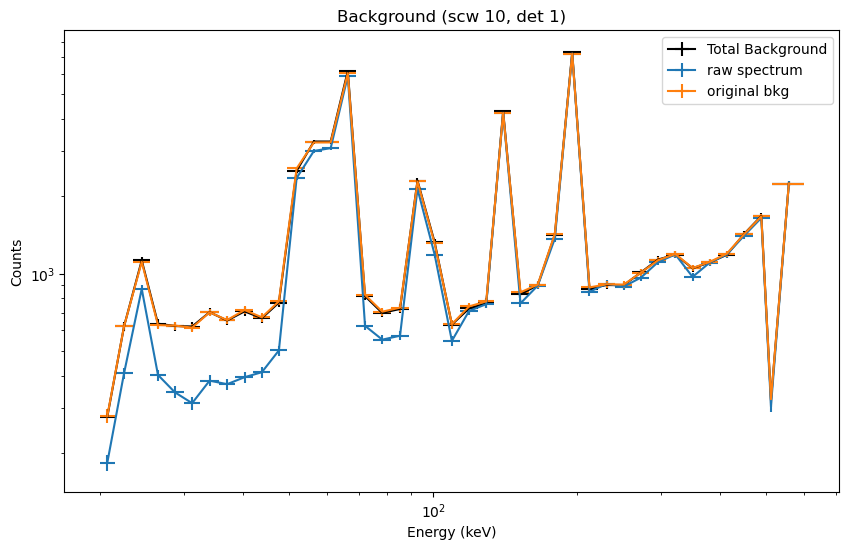

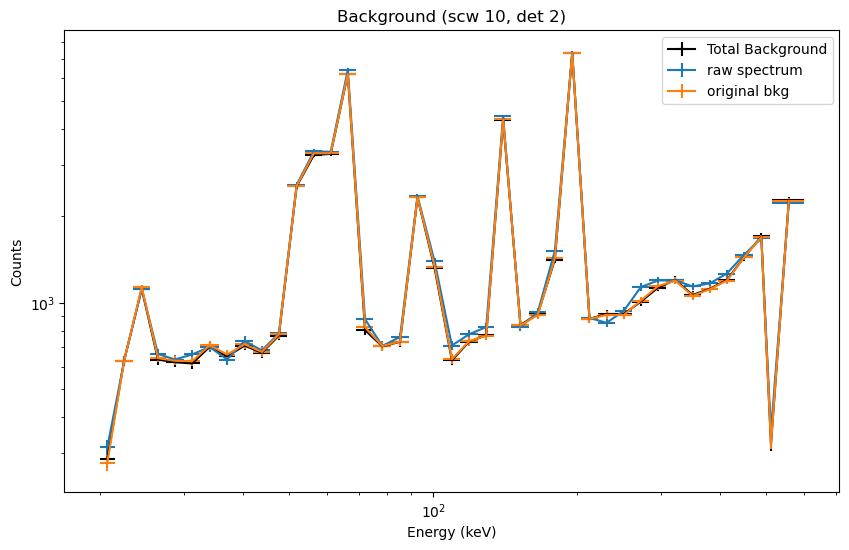

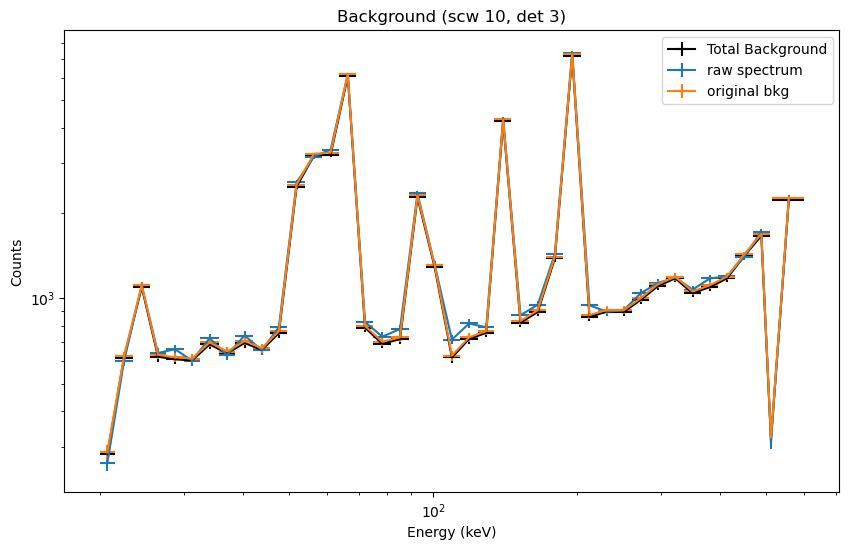

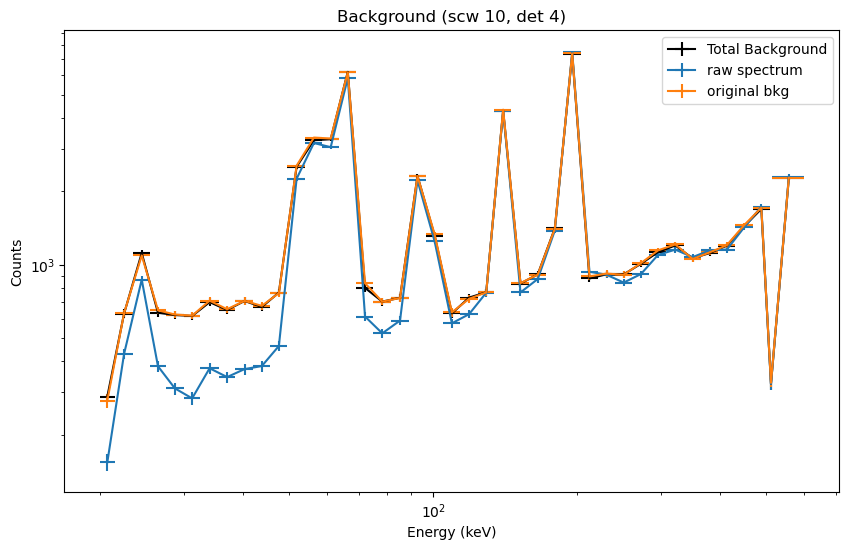

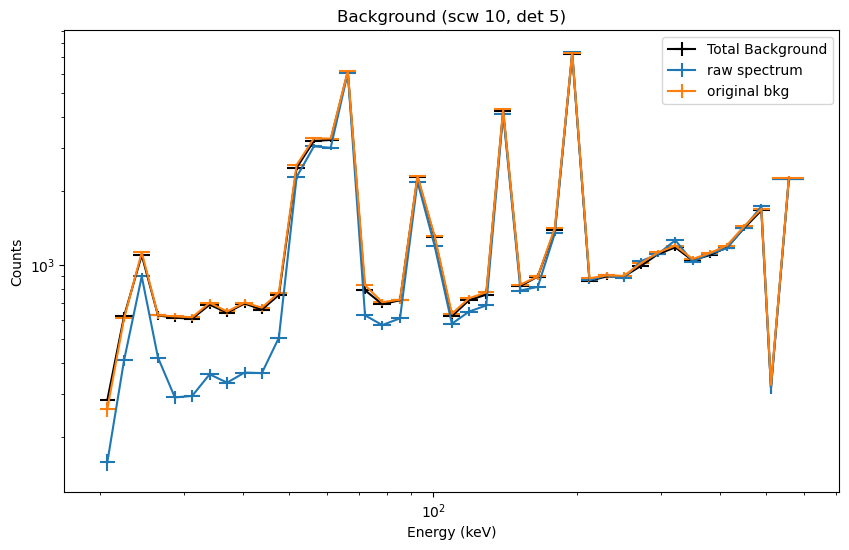

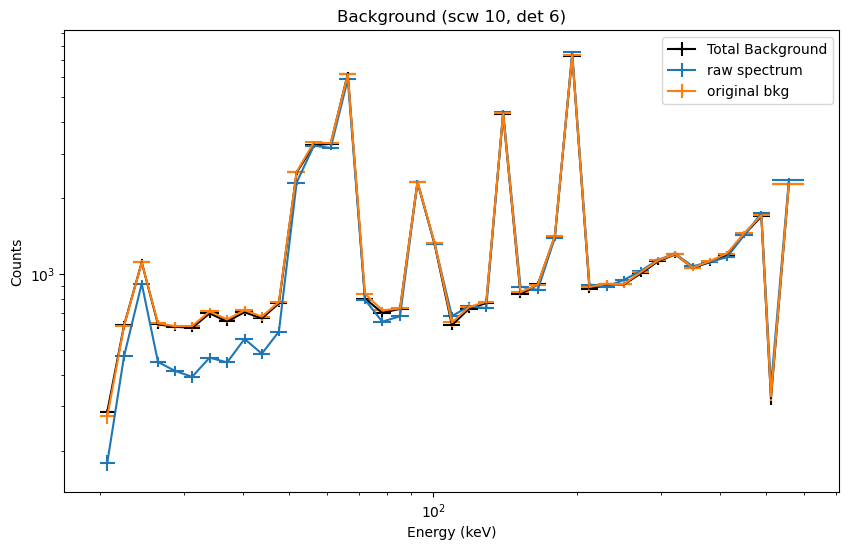

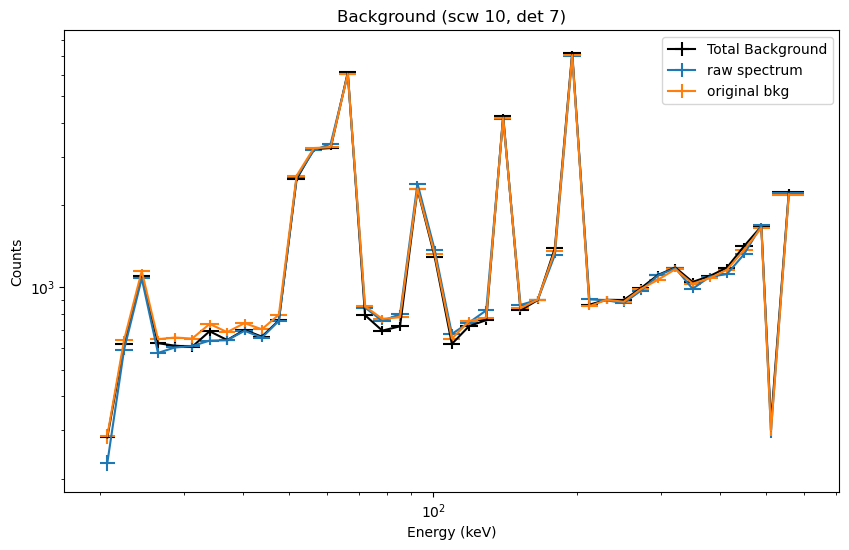

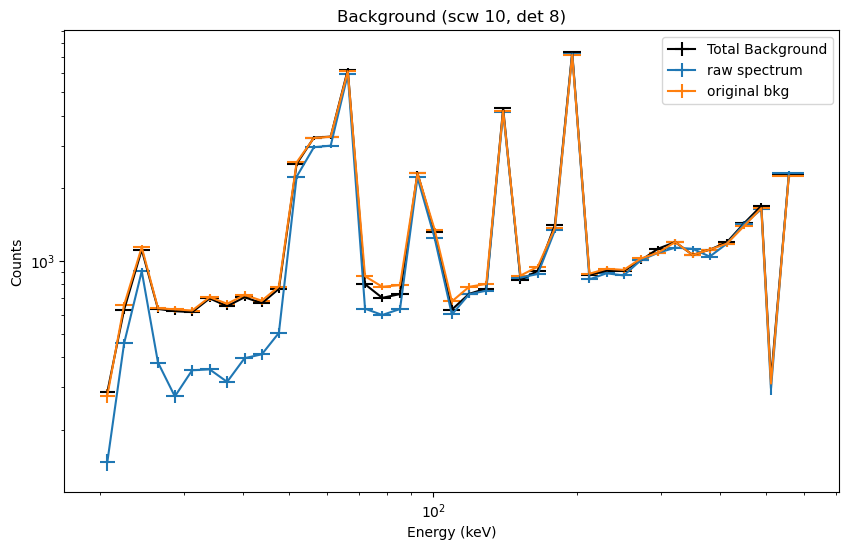

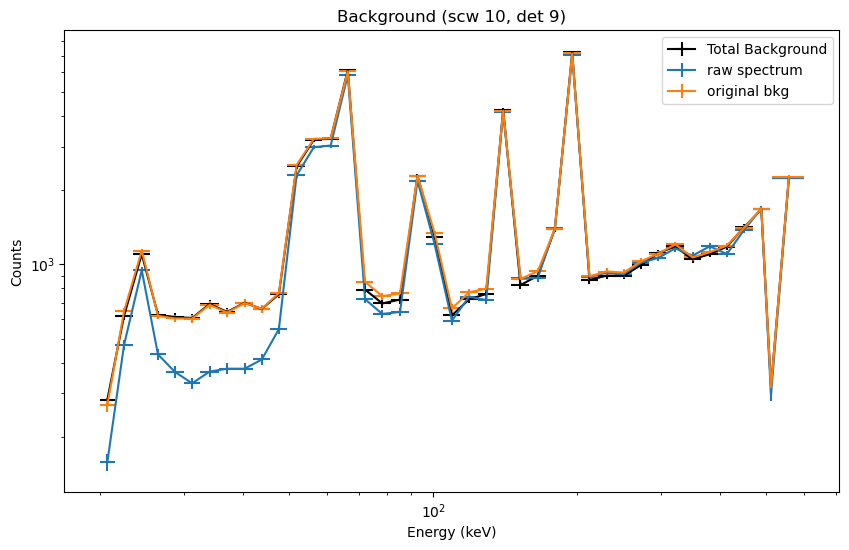

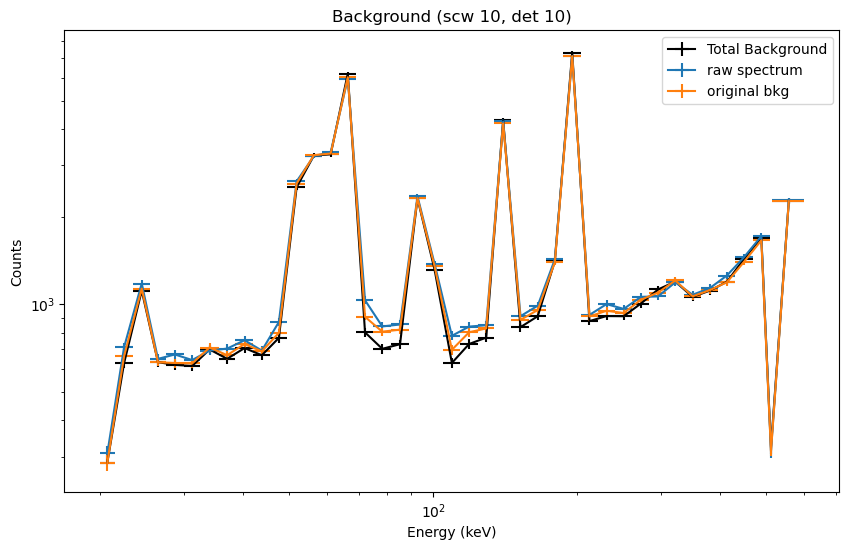

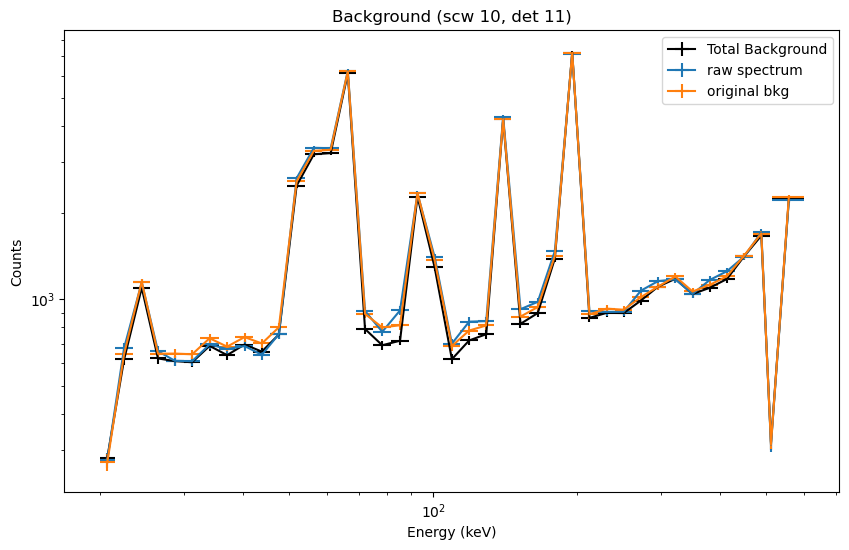

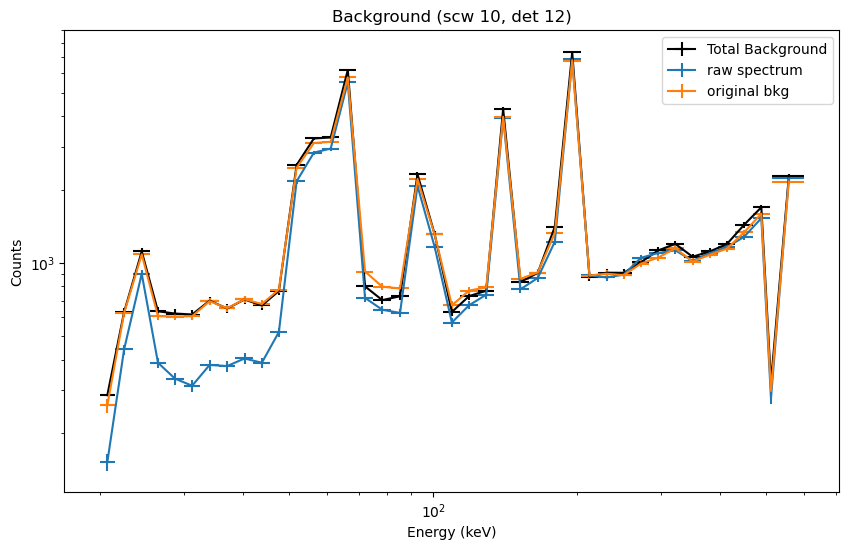

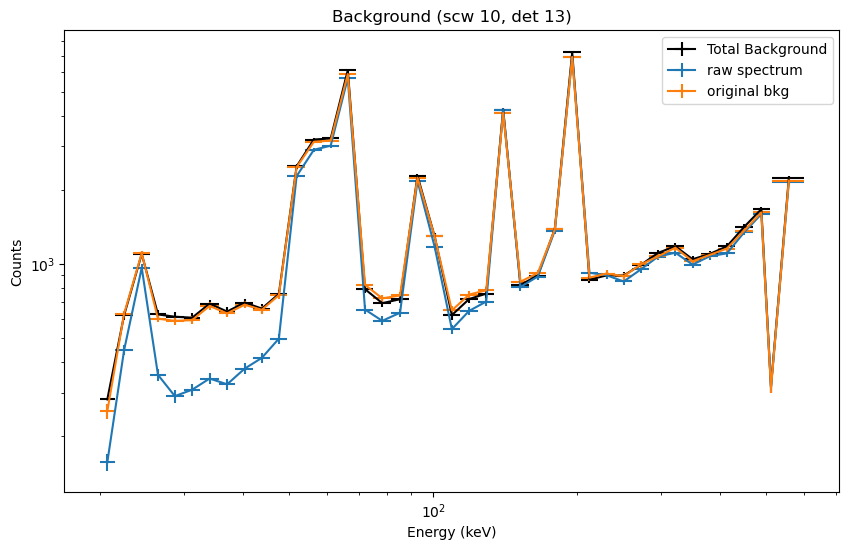

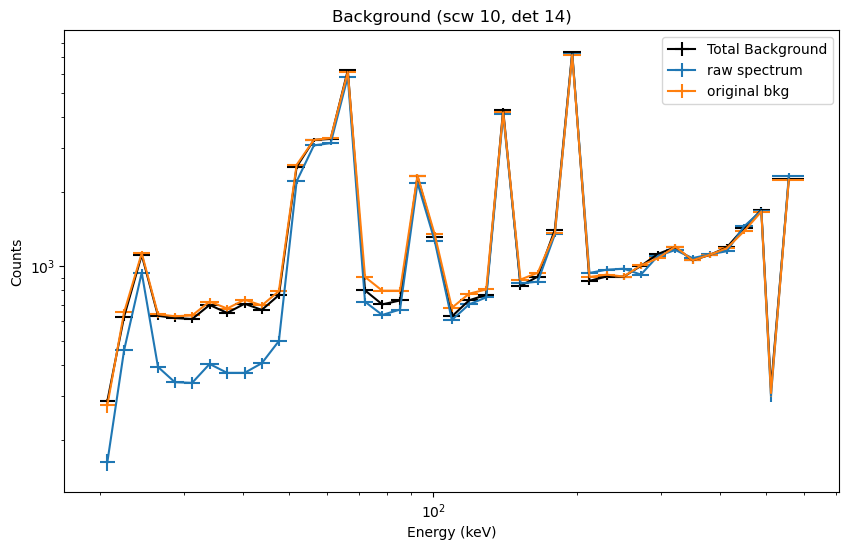

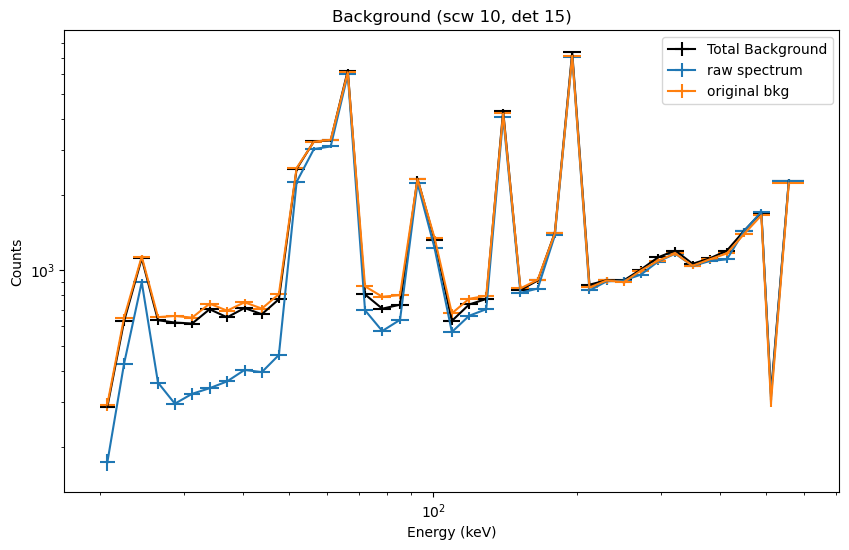

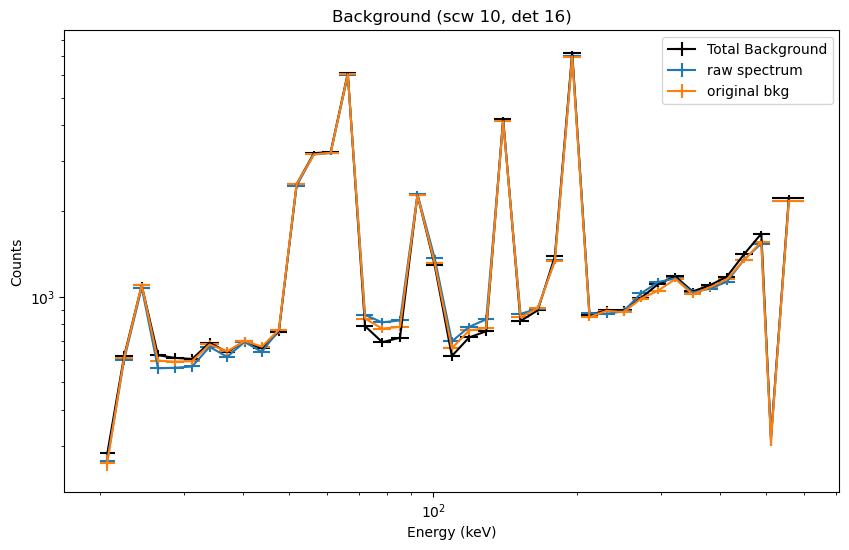

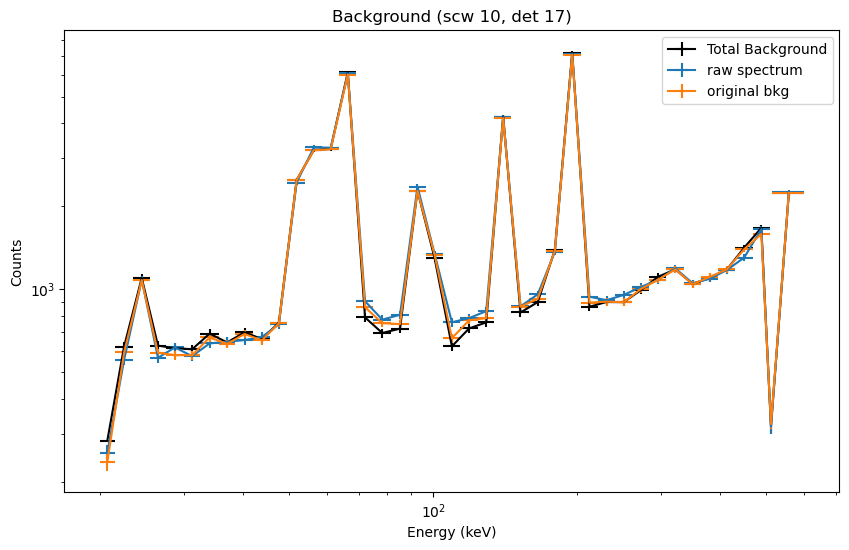

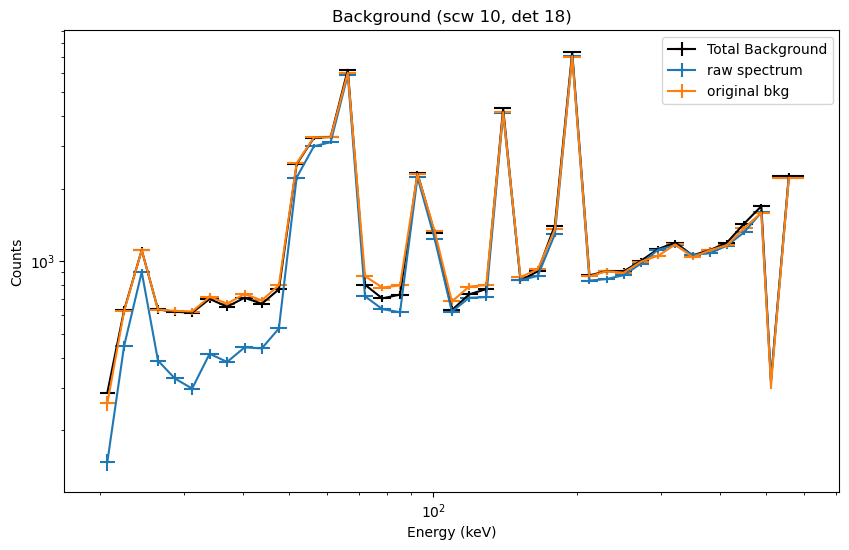

In [6]:
evts_name = f'{main_dir}/spi/evts_det_spec.fits.gz'
# poin_name = [strtrim(string('/pointing.fits.gz'),1),strtrim(string('/pointings.fits.gz'),1)]
# e_lo, e_hi = 30, 350 # kev
# SE_range =  18.25 + np.arange(3964) * 0.5
# E_idx_mask = (SE_range>e_lo) & (SE_range<e_hi)
scw_raw_spec = fits.open(evts_name)[1].data
scw_idx = 10
for det in range(19):
    # fig, ax=plt.subplots(1,1)
    ax=obs_bkg.plot_bkg(scw_idx,det,bkg_types=None)
    ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y=scw_raw_spec[scw_idx*19+det][0], yerr=scw_raw_spec[scw_idx*19+det][1], label='raw spectrum')
    ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y= data_conti[scw_idx*19+det][0]+data_sumlines[scw_idx*19+det][0], yerr=data_conti[scw_idx*19+det][1],label='original bkg')
    # ax.errorbar( bkg_spectrum, yerr=np.sqrt(bkg_spectrum), fmt='k-', label=label)
    ax.set_xlabel('Energy (keV)')
    ax.legend()
    ax.loglog()
    plt.show()

In [3]:
a={'a':2, 'b':3}
{i:a[i] for i in a.keys()}

{'a': 2, 'b': 3}